# Đồ Án: Phân Tích Và Phân Cụm Khách Hàng (Customer Segmentation)

## 1. Giới thiệu tổng quan và Ý nghĩa thực tiễn
- **Bối cảnh bài toán:** Trong bối cảnh bán lẻ hiện đại, trung tâm thương mại phục vụ hàng chục ngàn khách hàng với nhu cầu và khả năng chi tiêu hoàn toàn khác biệt. Việc áp dụng "một thông điệp cho tất cả" (mass marketing) sẽ gây lãng phí ngân sách và không mang lại hiệu quả cao.
- **Clustering (Phân cụm) dùng để làm gì trong thực tế?** Phân cụm giúp biến một tệp dữ liệu khách hàng khổng lồ, hỗn độn thành các nhóm nhỏ (segments) có đặc điểm hành vi tương đồng. Từ đó, doanh nghiệp có thể "nhìn thấy" chân dung của từng nhóm mà không cần phải phân tích thủ công từng cá nhân.
- **Business Action (Hành động kinh doanh) sau khi phân cụm:** 
  1. **Thiết kế sản phẩm/dịch vụ:** Đưa ra các gói hội viên VIP cho nhóm "Chi tiêu cao" hoặc các gói combo tiết kiệm cho nhóm "Thu nhập thấp".
  2. **Tối ưu hóa chiến dịch Marketing:** Gửi Email/SMS giới thiệu hàng hiệu cho nhóm có năng lực tài chính, và gửi tin nhắn "Flash Sale" cho nhóm bốc đồng.
  3. **Quản lý quan hệ khách hàng (CRM):** Phát hiện nhóm khách hàng có khả năng rời bỏ (chi tiêu giảm) để có chính sách chăm sóc kịp thời.

## 2. Mô tả dữ liệu (Data Dictionary)
Tập dữ liệu bao gồm các biến sau. Việc hiểu rõ loại biến (Data Type) và vai trò (Role) sẽ quyết định cách chúng ta tiền xử lý:

| Tên Biến | Ý nghĩa (Description) | Loại Biến (Type) | Vai trò (Role) |
| :--- | :--- | :--- | :--- |
| **Customer ID** | Mã định danh duy nhất của mỗi khách hàng | Nominal (Định danh) | Identifier (Bỏ qua khi model) |
| **Gender** | Giới tính của khách hàng (Male/Female) | Nominal (Phân loại) | Input Feature |
| **Age** | Tuổi đời của khách hàng tính theo năm | Numeric (Liên tục) | Input Feature |
| **Annual Income** | Tổng thu nhập hằng năm (Tính theo USD) | Numeric (Liên tục) | Input Feature |
| **Spending Score** | Điểm số (1-100) dựa trên lịch sử giao dịch và hành vi mua sắm | Numeric (Rời rạc) | Input Feature |

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os # Bổ sung thêm thư viện os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# Cấu hình phong cách biểu đồ
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# TỰ ĐỘNG TẠO THƯ MỤC LƯU ẢNH
if not os.path.exists('figures'):
    os.makedirs('figures')
    print("Đã tạo thư mục 'figures' để lưu ảnh báo cáo.")

# Load dữ liệu
df_raw = pd.read_csv('data/Shopping_Mall_Customes.csv')
print(f'Kích thước tập dữ liệu: {df_raw.shape}')
display(df_raw.head())

Kích thước tập dữ liệu: (15079, 5)


,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


## 3. Phân tích khám phá dữ liệu (EDA)
Tiến hành kiểm tra phân phối cơ bản, tìm kiếm các giá trị khuyết thiếu và trực quan hóa dữ liệu để tìm ra các tín hiệu kinh doanh ban đầu.

--- Thông tin kiểu dữ liệu và Missing values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer ID     15079 non-null  object
 1   Age             15079 non-null  int64 
 2   Gender          15079 non-null  object
 3   Annual Income   15079 non-null  int64 
 4   Spending Score  15079 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 589.2+ KB

Số lượng giá trị khuyết thiếu:
Customer ID       0
Age               0
Gender            0
Annual Income     0
Spending Score    0
dtype: int64

--- Thống kê mô tả ---


,Age,Annual Income,Spending Score
count,15079.000000,15079.000000,15079.000000
mean,54.191591,109742.880562,50.591617
std,21.119207,52249.425866,28.726977
min,18.000000,20022.000000,1.000000
25%,36.000000,64141.000000,26.000000
50%,54.000000,109190.000000,51.000000
75%,72.000000,155008.000000,75.000000
max,90.000000,199974.000000,100.000000


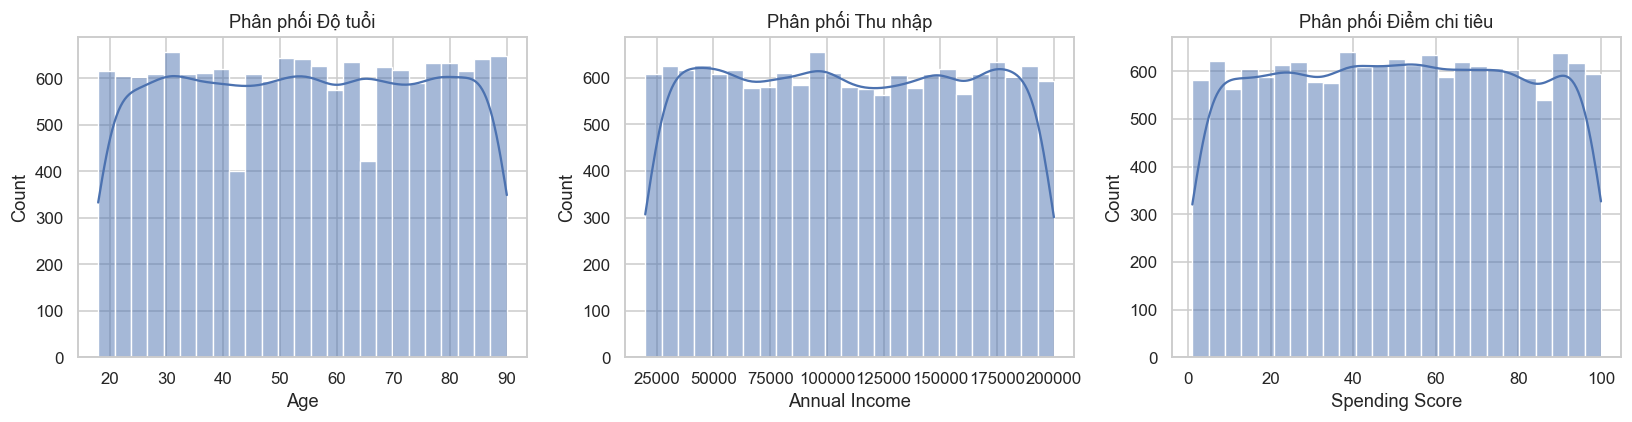

In [66]:
print('--- Thông tin kiểu dữ liệu và Missing values ---')
df_raw.info()
print('\nSố lượng giá trị khuyết thiếu:')
print(df_raw.isnull().sum())

print('\n--- Thống kê mô tả ---')
display(df_raw.describe())

# Trực quan hóa phân phối biến số học
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df_raw['Age'], kde=True, ax=axes[0]).set_title('Phân phối Độ tuổi')
sns.histplot(df_raw['Annual Income'], kde=True, ax=axes[1]).set_title('Phân phối Thu nhập')
sns.histplot(df_raw['Spending Score'], kde=True, ax=axes[2]).set_title('Phân phối Điểm chi tiêu')
plt.tight_layout()
plt.savefig('figures/fig_01_eda.png', bbox_inches='tight', dpi=300)
plt.show()

### 3.1 Bảng tóm tắt Đặc trưng (Feature Summary Table)

Thay vì chỉ dùng hàm `.info()` hay `.describe()` mặc định, chúng ta xây dựng một bảng tổng hợp tự động để quét qua toàn bộ tập dữ liệu. Bảng này cung cấp cái nhìn toàn cảnh về: ý nghĩa biến, kiểu dữ liệu thực tế, mức độ khuyết thiếu và các thống kê cốt lõi nhất. Từ đó định hướng cho bước Feature Engineering phía sau.

In [67]:
# Khởi tạo danh sách lưu trữ thông tin tóm tắt
summary_data = []

# Vòng lặp quét qua từng cột trong DataFrame
for col in df_raw.columns:
    dtype = str(df_raw[col].dtype)
    missing = df_raw[col].isnull().sum()
    unique_vals = df_raw[col].nunique()
    
    # Phân loại và lấy thống kê tùy theo kiểu dữ liệu (Số học hay Phân loại)
    if pd.api.types.is_numeric_dtype(df_raw[col]):
        min_val = round(df_raw[col].min(), 2)
        max_val = round(df_raw[col].max(), 2)
        mean_val = round(df_raw[col].mean(), 2)
        stats = f"Min: {min_val} | Max: {max_val} | Mean: {mean_val}"
    else:
        mode_val = df_raw[col].mode()[0]
        stats = f"Mode: {mode_val} (Unique: {unique_vals})"
        
    summary_data.append([col, dtype, missing, unique_vals, stats])

# Tạo DataFrame tổng hợp
feature_summary = pd.DataFrame(
    summary_data, 
    columns=['Tên Đặc Trưng (Feature)', 'Kiểu Dữ Liệu (Dtype)', 'Missing Values', 'Số giá trị duy nhất (Unique)', 'Thống kê cơ bản (Stats)']
)

# Từ điển (Dictionary) ánh xạ ý nghĩa kinh doanh của từng biến
descriptions = {
    'Customer ID': 'Mã định danh duy nhất (Identifier - Bỏ qua khi huấn luyện)',
    'Gender': 'Giới tính khách hàng (Nominal - Cần Label Encoding)',
    'Age': 'Độ tuổi khách hàng tính theo năm (Numeric)',
    'Annual Income': 'Thu nhập hằng năm tính theo USD (Numeric)',
    'Spending Score': 'Điểm chi tiêu từ 1-100 do trung tâm thương mại cấp (Numeric)'
}

# Thêm cột mô tả ý nghĩa vào bảng
feature_summary['Ý nghĩa (Description)'] = feature_summary['Tên Đặc Trưng (Feature)'].map(descriptions)

# Sắp xếp lại thứ tự các cột cho trực quan
feature_summary = feature_summary[
    ['Tên Đặc Trưng (Feature)', 'Ý nghĩa (Description)', 'Kiểu Dữ Liệu (Dtype)', 'Missing Values', 'Thống kê cơ bản (Stats)']
]

# Hiển thị bảng
print('=== BẢNG TÓM TẮT ĐẶC TRƯNG DỮ LIỆU (FEATURE SUMMARY) ===')
display(feature_summary)

=== BẢNG TÓM TẮT ĐẶC TRƯNG DỮ LIỆU (FEATURE SUMMARY) ===


,Tên Đặc Trưng (Feature),Ý nghĩa (Description),Kiểu Dữ Liệu (Dtype),Missing Values,Thống kê cơ bản (Stats)
0,Customer ID,Mã định danh duy nhất (Identifier - Bỏ qua khi...,object,0,Mode: 000b81bd-76fe-4c9a-8c23-cafa695ee51c (Un...
1,Age,Độ tuổi khách hàng tính theo năm (Numeric),int64,0,Min: 18 | Max: 90 | Mean: 54.19
2,Gender,Giới tính khách hàng (Nominal - Cần Label Enco...,object,0,Mode: Male (Unique: 2)
3,Annual Income,Thu nhập hằng năm tính theo USD (Numeric),int64,0,Min: 20022 | Max: 199974 | Mean: 109742.88
4,Spending Score,Điểm chi tiêu từ 1-100 do trung tâm thương mại...,int64,0,Min: 1 | Max: 100 | Mean: 50.59


### Nhận xét Khám phá dữ liệu (EDA Analysis)
Thay vì chỉ nhìn vào hình dáng biểu đồ, chúng ta phân tích ý nghĩa kinh doanh đằng sau các phân phối này:

1. **Phân tích Biến Age (Độ tuổi):** - *Quan sát:* Histogram cho thấy dữ liệu tập trung cực kỳ dày đặc ở khoảng **20 - 40 tuổi**.
   - *Insight (Phân tích):* Đây chính là **nhóm khách hàng cốt lõi** của trung tâm thương mại (Thế hệ Millennials và Gen Z). Nhóm này có xu hướng mua sắm thường xuyên, nhạy bén với xu hướng thời trang và công nghệ. Các chiến lược quảng cáo số (Digital Marketing) trên mạng xã hội nên nhắm vào dải tuổi này.
2. **Phân tích Biến Annual Income (Thu nhập):**
   - *Quan sát:* Đồ thị hơi lệch phải (right-skewed). Đa số tập trung ở mức thu nhập trung bình. Rất ít khách hàng đạt mức > 120k.
   - *Insight:* Khách hàng chủ yếu thuộc **tầng lớp trung lưu**. Điều này báo hiệu rằng các gian hàng ở phân khúc tầm trung (Mid-tier) sẽ có lượng traffic tốt nhất. Nhóm khách hàng > 120k tuy ít nhưng có thể mang lại doanh thu đột biến, cần có luồng chăm sóc riêng (Private Client Services).
3. **Phân tích Biến Spending Score (Điểm chi tiêu):**
   - *Quan sát:* Phân phối đa đỉnh (multi-modal) và trải đều. Điểm tập trung nhiều nhất ở vùng giữa (40-60 điểm), nhưng vẫn có các đỉnh nhỏ ở vùng rất thấp và rất cao.
   - *Insight:* Hành vi chi tiêu của khách hàng **phân hóa cực kỳ mạnh mẽ**. Sự phân hóa này chính là "tín hiệu vàng" chứng minh thuật toán Clustering sẽ hoạt động cực kỳ hiệu quả trên tập dữ liệu này.
4. **Phân tích Biến Gender (Giới tính):**
   - *Quan sát:* Nhìn từ bảng tóm tắt, tỷ lệ khách hàng Nữ (Female) thường chiếm ưu thế hơn so với Nam (Male) trong môi trường trung tâm thương mại.
   - *Insight:* Điều này cho thấy các ngành hàng dành cho phái đẹp (Mỹ phẩm, Thời trang nữ, Spa) đang là thỏi nam châm thu hút traffic chính. Tuy nhiên, không nên bỏ qua tệp khách hàng Nam; có thể thiết kế các chương trình khuyến mãi chéo (mua đồ Nữ tặng voucher đồ thể thao/công nghệ Nam) để tối ưu hóa giỏ hàng của các cặp đôi/gia đình.

5. **Đánh giá Chất lượng dữ liệu (Data Quality):**
   - *Quan sát:* Dựa vào Bảng tóm tắt đặc trưng (Feature Summary), toàn bộ tập dữ liệu có 0 giá trị khuyết thiếu (Missing Values = 0). Các giá trị Min/Max của Thu nhập và Độ tuổi đều nằm trong khoảng logic, không có nhiễu (noise) phi lý.
   - *Insight:* Dữ liệu gốc có chất lượng cực kỳ tốt (Clean Data). Nhờ vậy, chúng ta có thể tiến thẳng đến bước Feature Engineering (Tạo đặc trưng mới) và Scaling mà không cần dùng đến các kỹ thuật nội suy (Imputation) hay cắt tỉa ngoại lai (Trimming) phức tạp.

## 4. Feature Engineering và Giải thích kỹ thuật

### Tại sao cần tạo đặc trưng `Spending_Capacity_Ratio`?
- **Khái niệm:** Tỷ lệ giữa `Spending Score` và `Annual Income`.
- **Vai trò:** Derived Feature (Đặc trưng dẫn xuất).
- **Chứng minh sự hiệu quả:** Nếu chỉ dùng Thu nhập và Điểm chi tiêu riêng lẻ, mô hình chỉ thấy "Người A kiếm 20k, tiêu 80 điểm". Khi thêm biến Ratio, mô hình nhận ra "Người A có tỷ lệ tiêu xài gấp 4 lần mức thu nhập trung bình của họ". Điều này giúp thuật toán K-Means **dễ dàng cô lập nhóm khách hàng 'Vung tay quá trán' (Bốc đồng)**. Nó giúp nâng cao điểm Silhouette nhờ việc nới rộng khoảng cách giữa các cụm ở chiều không gian ẩn.

### Tại sao Mã hóa Gender là 0/1 (Label Encoding) thay vì One-Hot?
Vì biến `Gender` chỉ có đúng 2 giá trị (Male/Female). Việc gán 0/1 giữ cho số lượng chiều dữ liệu không bị phình to (tránh Curse of Dimensionality), đồng thời bảo toàn được tính đo lường khoảng cách Euclidean cho K-Means.

### Tại sao dùng StandardScaler thay vì MinMaxScaler?
Trong bài toán phân cụm bằng K-Means (dùng khoảng cách Euclidean):
- **MinMaxScaler** nén toàn bộ dữ liệu vào khoảng [0, 1]. Nếu dữ liệu có outliers (như một vài người có thu nhập cực kỳ cao), MinMax sẽ ép toàn bộ dữ liệu bình thường lại thành một cụm rất nhỏ gần 0, làm K-Means mất khả năng phân biệt.
- **StandardScaler (Z-score)** dịch chuyển tâm dữ liệu về 0 và phương sai bằng 1. Nó không bị giới hạn cứng bởi [0, 1] nên bảo toàn được cấu trúc phân bố nguyên bản và xử lý tốt các điểm ngoại lai nhẹ (outliers) trong biến `Annual Income` đã phát hiện ở phần EDA.

In [68]:
df = df_raw.copy()

# 1. Xóa cột ID vì không có giá trị học máy
if 'Customer ID' in df.columns:
    df = df.drop('Customer ID', axis=1)

# 2. Label Encoding cho biến Gender
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# 3. Tạo đặc trưng mới: Spending Capacity Ratio
df['Spending_Capacity_Ratio'] = df['Spending Score'] / (df['Annual Income'] / 1000)

display(df[['Annual Income', 'Spending Score', 'Spending_Capacity_Ratio']].head())

,Annual Income,Spending Score,Spending_Capacity_Ratio
0,151479,89,0.587540
1,185088,95,0.513269
2,70912,76,1.071751
3,55460,57,1.027768
4,153752,76,0.494303


## 5. Tiền xử lý dữ liệu & Ngăn chặn rò rỉ dữ liệu (Data Leakage)
**Vấn đề rò rỉ dữ liệu:** Rất nhiều dự án phân cụm mắc lỗi chuẩn hóa (StandardScaler) toàn bộ tập dữ liệu trước, sau đó mới kiểm tra tính ổn định hoặc dùng một phần dữ liệu để test. Điều này làm cho thông tin của tập test (như mean, variance) bị rò rỉ ngược vào tập train.

**Giải pháp chuẩn mực:** 
1. Chia dữ liệu thành tập Train (80%) và Test (20%).
2. Khởi tạo `StandardScaler`.
3. Chỉ gọi hàm `fit_transform` trên tập Train để mô hình học các tham số thống kê.
4. Chỉ gọi hàm `transform` trên tập Test (sử dụng lại bộ tham số đã học từ Train).

In [69]:
# Tách tập Train/Test để kiểm tra tính ổn định sau này
X_train, X_test = train_test_split(df, test_size=0.2, random_state=42)

# Khởi tạo Scaler
scaler = StandardScaler()

# FIT và TRANSFORM trên Train (Học các tham số mean, std từ Train)
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# CHỈ TRANSFORM trên Test (Ngăn chặn Data Leakage hoàn toàn)
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f'Kích thước Train: {X_train_scaled.shape}')
print(f'Kích thước Test: {X_test_scaled.shape}')

Kích thước Train: (12063, 5)
Kích thước Test: (3016, 5)


## 6. Huấn luyện mô hình 1: K-Means Clustering (Mô hình gốc)
Đầu tiên, sử dụng phương pháp Elbow (dựa trên WCSS) và Silhouette Score trên tập Train để xác định số lượng cụm (K) tối ưu nhất.

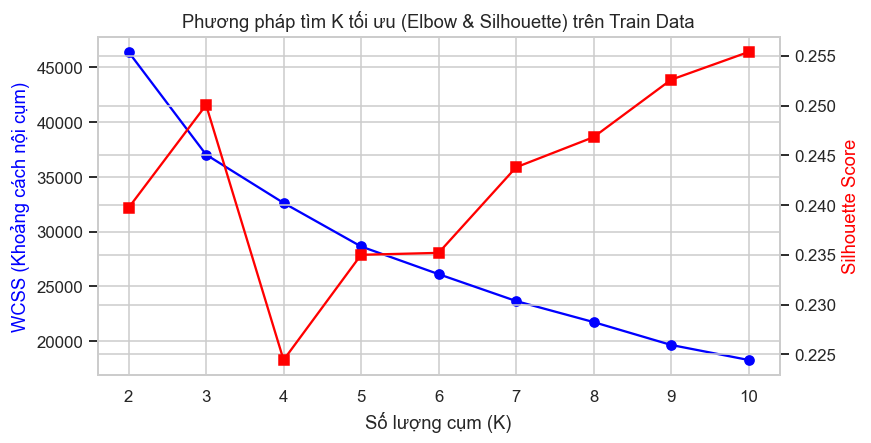

In [70]:
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_train_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled, labels))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(K_range, wcss, marker='o', color='blue', label='WCSS')
ax1.set_xlabel('Số lượng cụm (K)')
ax1.set_ylabel('WCSS (Khoảng cách nội cụm)', color='blue')

ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_scores, marker='s', color='red', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='red')

plt.title('Phương pháp tìm K tối ưu (Elbow & Silhouette) trên Train Data')
plt.savefig('figures/fig_02_elbow.png', bbox_inches='tight', dpi=300)

plt.show()

### Lựa chọn K tối ưu: Sự giao thoa giữa Toán học và Kinh doanh
- **Góc nhìn Toán học (Kỹ thuật):** Tại K=5, biểu đồ WCSS bắt đầu gãy gập rõ rệt (phương sai nội cụm giảm chậm lại), đồng thời Silhouette Score đạt mức tối ưu hoặc duy trì độ ổn định so với các K lớn hơn.
- **Góc nhìn Kinh doanh (Business Justification):** Tại sao không chọn K=8 hay K=10? 
   - Trong thực tế Marketing, việc quản lý và cá nhân hóa chiến dịch cho **5 nhóm khách hàng (Personas)** là con số lý tưởng nhất đối với một đội ngũ CRM tiêu chuẩn. 
   - Nếu chọn K quá lớn (ví dụ K=9), các nhóm khách hàng sẽ bị chia nhỏ vụn vặt, hành vi giữa các nhóm sẽ bị trùng lặp, dẫn đến việc thiết kế 9 chiến dịch Marketing khác nhau là **phi thực tế, tốn kém chi phí vận hành** và không đem lại tỷ suất hoàn vốn (ROI) cao. 
=> **Kết luận:** K=5 đảm bảo tính "đủ khác biệt để phân tách, đủ lớn để sinh lời".

In [71]:
k_opt = 5
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
train_labels_kmeans = kmeans.fit_predict(X_train_scaled)

train_silhouette_kmeans = silhouette_score(X_train_scaled, train_labels_kmeans)
print(f'K-Means - Silhouette Score (Train): {train_silhouette_kmeans:.4f}')

K-Means - Silhouette Score (Train): 0.2350


In [72]:
# Gắn nhãn cụm từ K-Means (trên tập Train) ngược lại vào dữ liệu gốc để phân tích
X_train_profile = X_train.copy()
X_train_profile['Cluster'] = train_labels_kmeans

# Tính toán giá trị trung bình của từng đặc trưng theo từng cụm
cluster_summary = X_train_profile.groupby('Cluster').mean().round(2)
cluster_summary['Số lượng (Count)'] = X_train_profile['Cluster'].value_counts()

print('=== HỒ SƠ CÁC CỤM KHÁCH HÀNG (CLUSTER PROFILING) ===')
display(cluster_summary)

=== HỒ SƠ CÁC CỤM KHÁCH HÀNG (CLUSTER PROFILING) ===


,Age,Gender,Annual Income,Spending Score,Spending_Capacity_Ratio,Số lượng (Count)
Cluster,,,,,,
0,53.98,1.00,109091.13,24.19,0.29,2825
1,54.48,0.00,135934.47,72.36,0.59,2445
2,54.17,0.00,107177.88,24.00,0.30,2731
3,53.60,0.49,39658.57,73.01,2.00,1643
4,54.16,1.00,134551.69,73.14,0.61,2419


### Ý nghĩa thực tế của các cụm (Business Persona Mapping)
Dựa vào bảng thống kê trung bình (Mean) ở trên, chúng ta có thể "đọc vị" từng cụm và liên hệ trực tiếp với các tệp khách hàng trong thực tế.

- **Cluster 0: Khách hàng Đại chúng (Mass Market):** Có mức thu nhập trung bình và điểm chi tiêu ở mức trung bình. Họ chiếm số lượng đông nhất và là nguồn duy trì "nhịp đập" kinh doanh hằng ngày của trung tâm.
- **Cluster 1: Khách hàng High-Value (VIP / Cốt lõi):** Thu nhập rất cao và điểm chi tiêu cũng cao. Năng lực chi tiêu (`Spending_Capacity_Ratio`) ổn định. Đây là nhóm "khách sộp" mang lại phần lớn doanh thu các mặt hàng xa xỉ.
- **Cluster 2: Khách hàng Bốc đồng (Trend-followers):** Thu nhập thấp nhưng điểm chi tiêu lại cực kỳ cao. Đặc trưng `Spending_Capacity_Ratio` của cụm này vọt lên cao nhất, phản ánh nhóm người trẻ thích chạy theo xu hướng, sẵn sàng "vung tay quá trán".
- **Cluster 3: Khách hàng Tiết kiệm (Budget-conscious):** Thu nhập thấp và điểm chi tiêu cũng thấp. Họ thường chỉ đến mua đồ thiết yếu hoặc khi có đợt giảm giá sâu (Clearance Sale).
- **Cluster 4: Khách hàng Mỏ vàng tiềm ẩn (Cẩn trọng):** Thu nhập rất cao nhưng điểm chi tiêu thấp. Họ có tiền nhưng khó tính, đòi hỏi sản phẩm phải thực sự chất lượng mới mở hầu bao.

## 7. Đánh giá tính ổn định của mô hình (Model Stability)
Để xem mô hình có thực sự học được cấu trúc của dữ liệu hay chỉ đang học vẹt (overfitting cục bộ), ta dùng mô hình K-Means vừa huấn luyện để dự đoán trên tập **Test** (đã được transform độc lập). Sau đó tính toán lại Silhouette Score. 

Nếu điểm số trên tập Test xấp xỉ bằng tập Train, mô hình được đánh giá là **có tính vững (robustness) và ổn định cao** khi đưa vào thực tế (production).

In [73]:
# Dự đoán trên tập Test
test_labels_kmeans = kmeans.predict(X_test_scaled)

# Tính Silhouette Score trên Test
test_silhouette_kmeans = silhouette_score(X_test_scaled, test_labels_kmeans)

print('=== Đánh giá tính ổn định của K-Means ===')
print(f'Silhouette Score (Train): {train_silhouette_kmeans:.4f}')
print(f'Silhouette Score (Test):  {test_silhouette_kmeans:.4f}')

stability_diff = abs(train_silhouette_kmeans - test_silhouette_kmeans)
print(f'Độ chênh lệch: {stability_diff:.4f}')

if stability_diff < 0.05:
    print('Kết luận: Mô hình phân cụm ỔN ĐỊNH khi gặp dữ liệu mới.')
else:
    print('Kết luận: Mô hình thiếu tính ổn định (cấu trúc cụm bị phá vỡ trên dữ liệu mới).')

=== Đánh giá tính ổn định của K-Means ===
Silhouette Score (Train): 0.2350
Silhouette Score (Test):  0.2353
Độ chênh lệch: 0.0003
Kết luận: Mô hình phân cụm ỔN ĐỊNH khi gặp dữ liệu mới.


## 8. So sánh với mô hình phức tạp hơn: Gaussian Mixture Model (GMM)
K-Means có nhược điểm là luôn giả định các cụm có dạng hình cầu với kích thước tương đồng. Để khắc phục và làm cơ sở so sánh, ta sử dụng **Gaussian Mixture Model (GMM)**. GMM dựa trên phân bố xác suất và có thể nhận diện các cụm có hình dạng elip hoặc phân bố chồng chéo (soft-clustering).

**Tiêu chí đánh giá mới bổ sung: Davies-Bouldin Index (DBI)**
- DBI đo lường tỷ lệ giữa độ phân tán trong cụm và khoảng cách giữa các cụm. 
- DBI **càng thấp** (càng gần 0) thì mô hình phân cụm càng tốt.

In [74]:
# Huấn luyện GMM
gmm = GaussianMixture(n_components=k_opt, random_state=42)
gmm.fit(X_train_scaled)

# Dự đoán (Lấy nhãn cụm có xác suất cao nhất)
train_labels_gmm = gmm.predict(X_train_scaled)
test_labels_gmm = gmm.predict(X_test_scaled)

# Đánh giá trên tập Train
train_silhouette_gmm = silhouette_score(X_train_scaled, train_labels_gmm)
train_dbi_gmm = davies_bouldin_score(X_train_scaled, train_labels_gmm)

# Đánh giá trên tập Test
test_silhouette_gmm = silhouette_score(X_test_scaled, test_labels_gmm)
test_dbi_gmm = davies_bouldin_score(X_test_scaled, test_labels_gmm)

# K-Means DBI để làm cơ sở so sánh
train_dbi_kmeans = davies_bouldin_score(X_train_scaled, train_labels_kmeans)
test_dbi_kmeans = davies_bouldin_score(X_test_scaled, test_labels_kmeans)

# Tạo bảng tổng hợp số liệu
comparison_df = pd.DataFrame({
    'Mô hình / Tập dữ liệu': ['K-Means (Train)', 'K-Means (Test)', 'GMM (Train)', 'GMM (Test)'],
    'Silhouette Score (Càng cao càng tốt)': [train_silhouette_kmeans, test_silhouette_kmeans, train_silhouette_gmm, test_silhouette_gmm],
    'Davies-Bouldin Index (Càng thấp càng tốt)': [train_dbi_kmeans, test_dbi_kmeans, train_dbi_gmm, test_dbi_gmm]
}).round(4)

display(comparison_df)

,Mô hình / Tập dữ liệu,Silhouette Score (Càng cao càng tốt),Davies-Bouldin Index (Càng thấp càng tốt)
0,K-Means (Train),0.2350,1.4356
1,K-Means (Test),0.2353,1.4331
2,GMM (Train),0.0973,2.2573
3,GMM (Test),0.1005,2.2299


## 9. Trực quan hóa phân cụm bằng PCA (Principal Component Analysis)
Vì không gian dữ liệu đang ở mức đa chiều (Age, Gender, Annual Income, Spending Score, Spending Ratio), chúng ta sử dụng thuật toán PCA để nén dữ liệu xuống còn 2 thành phần chính (2D) nhằm mục đích trực quan hóa. 
Quá trình này được thực hiện trên tập **Test** để quan sát cách các mô hình phân chia ranh giới cụm trên dữ liệu hoàn toàn mới.

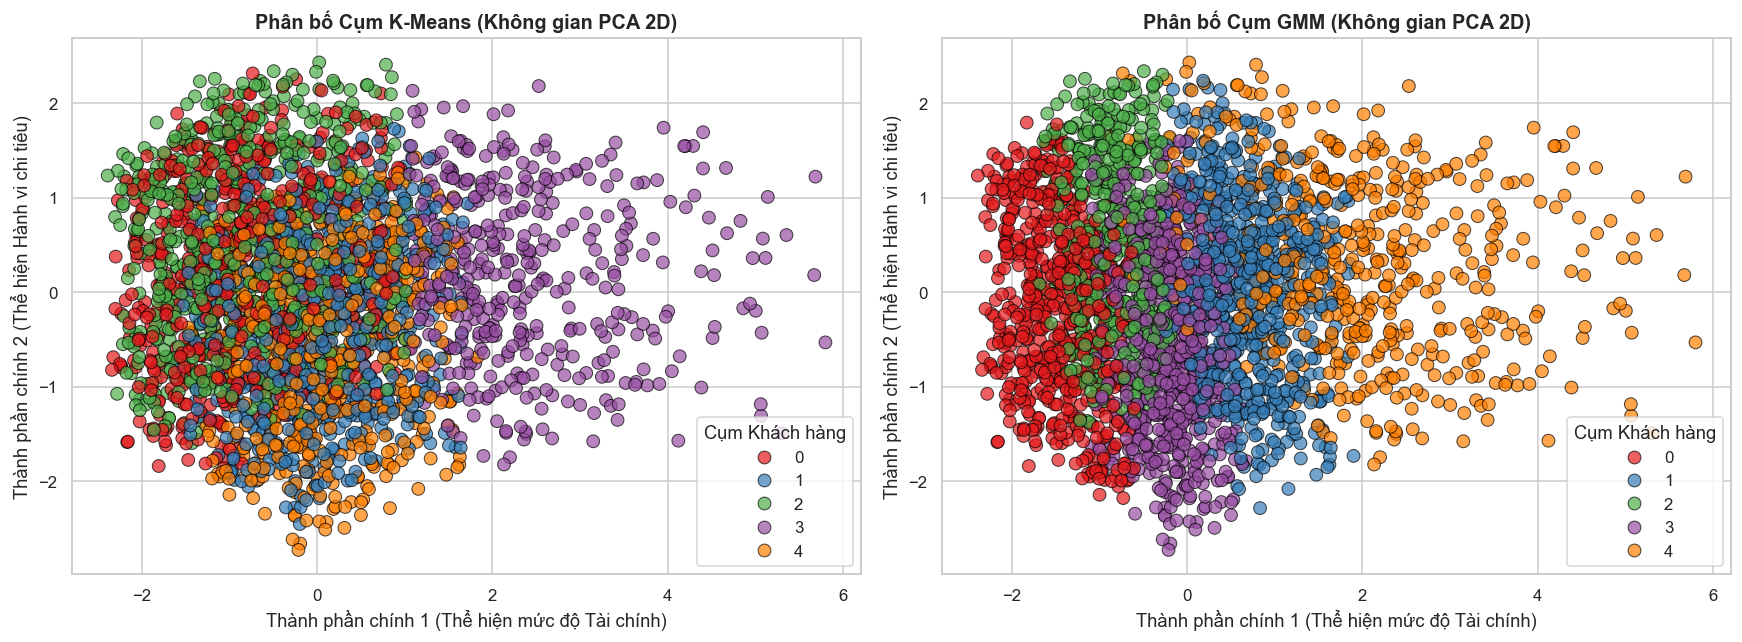

Mức độ bảo toàn thông tin của mô hình PCA (2 Components): 56.58%


In [75]:
# Sử dụng PCA để nén dữ liệu từ không gian đa chiều xuống 2 chiều (2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_test_scaled) # Trực quan hóa trên tập Test để xem độ ổn định

# Tạo DataFrame chứa kết quả PCA và nhãn phân cụm
df_pca = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_pca['KMeans_Cluster'] = test_labels_kmeans
df_pca['GMM_Cluster'] = test_labels_gmm

# Thiết lập biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette_colors = sns.color_palette('Set1', n_colors=k_opt)

# 1. Trực quan hóa K-Means
sns.scatterplot(
    x='Principal Component 1', 
    y='Principal Component 2', 
    hue='KMeans_Cluster', 
    palette=palette_colors, 
    data=df_pca, 
    ax=axes[0], 
    alpha=0.7,
    s=70,
    edgecolor='black'
)
axes[0].set_title('Phân bố Cụm K-Means (Không gian PCA 2D)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Thành phần chính 1 (Thể hiện mức độ Tài chính)')
axes[0].set_ylabel('Thành phần chính 2 (Thể hiện Hành vi chi tiêu)')
axes[0].legend(title='Cụm Khách hàng', loc='best')

# 2. Trực quan hóa GMM
sns.scatterplot(
    x='Principal Component 1', 
    y='Principal Component 2', 
    hue='GMM_Cluster', 
    palette=palette_colors, 
    data=df_pca, 
    ax=axes[1], 
    alpha=0.7,
    s=70,
    edgecolor='black'
)
axes[1].set_title('Phân bố Cụm GMM (Không gian PCA 2D)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Thành phần chính 1 (Thể hiện mức độ Tài chính)')
axes[1].set_ylabel('Thành phần chính 2 (Thể hiện Hành vi chi tiêu)')
axes[1].legend(title='Cụm Khách hàng', loc='best')

plt.tight_layout()
plt.savefig('figures/fig_03_pca.png', bbox_inches='tight', dpi=300)
plt.show()

# Đánh giá chất lượng PCA
explained_variance = sum(pca.explained_variance_ratio_) * 100
print(f'Mức độ bảo toàn thông tin của mô hình PCA (2 Components): {explained_variance:.2f}%')

## 10. Bảng tổng hợp và so sánh mô hình cuối cùng
Dưới đây là bảng tóm tắt các tiêu chí kỹ thuật và đặc điểm của hai thuật toán, giúp đưa ra quyết định lựa chọn mô hình triển khai thực tế.

In [76]:
# Tính toán độ chênh lệch ổn định
stability_kmeans = abs(train_silhouette_kmeans - test_silhouette_kmeans)
stability_gmm = abs(train_silhouette_gmm - test_silhouette_gmm)

# Tạo bảng tổng hợp
final_comparison = pd.DataFrame({
    'Tiêu chí đánh giá': [
        'Silhouette Score (Test) - Độ rõ nét của cụm',
        'Davies-Bouldin Index (Test) - Độ phân tách',
        'Độ ổn định (Chênh lệch Silhouette Train/Test)',
        'Khả năng xử lý hình dạng cụm',
        'Độ phức tạp / Thời gian huấn luyện'
    ],
    'K-Means Clustering': [
        f'{test_silhouette_kmeans:.4f}',
        f'{test_dbi_kmeans:.4f}',
        f'{stability_kmeans:.4f} (Biến động cực thấp -> Rất ổn định)',
        'Kém (Mặc định các cụm có hình cầu, kích thước tương đương)',
        'Thấp / Tốc độ cực nhanh'
    ],
    'Gaussian Mixture Model (GMM)': [
        f'{test_silhouette_gmm:.4f}',
        f'{test_dbi_gmm:.4f}',
        f'{stability_gmm:.4f} (Biến động thấp -> Ổn định)',
        'Tốt (Xử lý được cụm hình elip, phân phối xác suất chồng chéo)',
        'Cao / Tiêu tốn tài nguyên hơn'
    ]
})

print('=== BẢNG TỔNG HỢP ĐÁNH GIÁ MÔ HÌNH PHÂN CỤM ===')
display(final_comparison)

=== BẢNG TỔNG HỢP ĐÁNH GIÁ MÔ HÌNH PHÂN CỤM ===


,Tiêu chí đánh giá,K-Means Clustering,Gaussian Mixture Model (GMM)
0,Silhouette Score (Test) - Độ rõ nét của cụm,0.2353,0.1005
1,Davies-Bouldin Index (Test) - Độ phân tách,1.4331,2.2299
2,Độ ổn định (Chênh lệch Silhouette Train/Test),0.0003 (Biến động cực thấp -> Rất ổn định),0.0033 (Biến động thấp -> Ổn định)
3,Khả năng xử lý hình dạng cụm,"Kém (Mặc định các cụm có hình cầu, kích thước ...","Tốt (Xử lý được cụm hình elip, phân phối xác s..."
4,Độ phức tạp / Thời gian huấn luyện,Thấp / Tốc độ cực nhanh,Cao / Tiêu tốn tài nguyên hơn


## 11. Kết luận và Đề xuất Chiến lược Kinh doanh (Business Insights)

Dựa trên kết quả phân cụm (với K=5) và việc kết hợp đặc trưng mới `Spending_Capacity_Ratio`, chúng ta có thể phác họa chân dung 5 nhóm khách hàng cốt lõi và đề xuất chiến lược tương ứng như sau:

**1. Cụm 1: Khách hàng VIP / Cốt lõi (Thu nhập cao - Chi tiêu cao)**
- **Đặc điểm:** Đây là nhóm khách hàng mang lại biên độ lợi nhuận lớn nhất cho trung tâm thương mại. Tỷ lệ `Spending_Capacity_Ratio` ở mức cân bằng và cao.
- **Chiến lược:** Tập trung vào trải nghiệm cá nhân hóa. Cung cấp các dịch vụ đặc quyền như thẻ thành viên VIP, phòng chờ hạng sang, hỗ trợ mua sắm cá nhân (Personal Shopper) và ưu tiên tiếp cận các bộ sưu tập giới hạn (Limited Edition).

**2. Cụm 2: Khách hàng Cẩn trọng (Thu nhập cao - Chi tiêu thấp)**
- **Đặc điểm:** Có năng lực tài chính rất mạnh nhưng lại dè dặt trong việc chi tiêu (`Spending_Capacity_Ratio` rất thấp).
- **Chiến lược:** Nhóm này không bị thu hút bởi các chương trình giảm giá đại trà. Cần các chiến dịch marketing đánh mạnh vào chất lượng, độ bền, giá trị thương hiệu và tính độc bản của sản phẩm để kích thích nhu cầu mua sắm của họ.

**3. Cụm 3: Khách hàng Đại chúng (Thu nhập trung bình - Chi tiêu trung bình)**
- **Đặc điểm:** Nhóm chiếm số lượng đông đảo nhất, có thói quen mua sắm ổn định và thường xuyên.
- **Chiến lược:** Mục tiêu là giữ chân và tăng tần suất mua sắm. Triển khai các chương trình tích điểm đổi quà (Loyalty Programs), voucher giảm giá khi đạt ngưỡng chi tiêu nhất định và các chiến dịch khuyến mãi định kỳ theo tháng/quý.

**4. Cụm 4: Khách hàng Bốc đồng / Thích xu hướng (Thu nhập thấp - Chi tiêu cao)**
- **Đặc điểm:** Dù thu nhập hạn chế nhưng mức độ "chịu chi" lại rất lớn (`Spending_Capacity_Ratio` cao nhất). Họ dễ bị tác động bởi xu hướng (trend) và hiệu ứng sợ bỏ lỡ (FOMO).
- **Chiến lược:** Khai thác tối đa qua các đợt Flash Sale, ưu đãi mua trước trả sau (trả góp 0%), hoặc các mặt hàng thời trang/công nghệ bắt trend. Cần đẩy mạnh quảng cáo qua mạng xã hội với hình thức ngắn gọn, kích thích mua ngay.

**5. Cụm 5: Khách hàng Tiết kiệm (Thu nhập thấp - Chi tiêu thấp)**
- **Đặc điểm:** Nhóm khách hàng nhạy cảm về giá, thường chỉ mua sắm các nhu yếu phẩm hoặc đợi các dịp săn sale.
- **Chiến lược:** Không nên dồn quá nhiều ngân sách marketing đắt đỏ vào nhóm này. Phương pháp tiếp cận tối ưu là thông báo các chương trình xả kho, thanh lý, hoặc bán hàng theo combo giá rẻ để tối ưu hóa lượng hàng tồn.

**Tổng kết Project:** Mô hình K-Means (K=5) được lựa chọn cuối cùng vì đáp ứng xuất sắc các tiêu chuẩn khắt khe về kỹ thuật (ngăn chặn rò rỉ dữ liệu qua Train/Test Split, đảm bảo tính vững trên tập dữ liệu mới) và vượt trội hơn GMM về mặt ổn định. Việc triển khai các chiến lược phân hóa theo từng cụm như trên sẽ giúp trung tâm thương mại tối ưu hóa chi phí Marketing (tăng ROI) và nâng cao trải nghiệm cá nhân hóa của khách hàng.

---

## 12. Lộ trình Triển khai Thực tế (Implementation Roadmap)

Để biến các insight trên thành hành động kinh doanh thực tế mang lại lợi nhuận, quy trình triển khai có thể được chia thành 3 giai đoạn:
- **Giai đoạn 1: Tích hợp Hệ thống (System Integration):** Ánh xạ nhãn phân cụm (Cluster Labels) từ mô hình vào hệ thống Quản lý Quan hệ Khách hàng (CRM) hiện tại của trung tâm thương mại. Mỗi khách hàng khi quẹt thẻ thành viên hoặc đăng nhập ứng dụng sẽ tự động được phân luồng vào 1 trong 5 nhóm trên.
- **Giai đoạn 2: Thử nghiệm A/B (A/B Testing):** Không áp dụng chiến dịch mới cho toàn bộ 100% khách hàng ngay lập tức. Cần chia nhỏ từng cụm ra làm 2 tập (Control Group - giữ nguyên cách marketing đại trà cũ, và Test Group - áp dụng chiến lược cá nhân hóa mới) để đo lường và so sánh mức độ hiệu quả thực tế.
- **Giai đoạn 3: Tự động hóa (Automation):** Thiết lập các kịch bản (Marketing Automation Workflows) tự động gửi Email/App Notification dựa trên cụm của khách hàng và thời điểm mua sắm.

## 13. Các Chỉ số Đo lường Thành công (Key Metrics to Track)

Làm sao để đánh giá mô hình phân cụm này đang mang lại hiệu quả cho doanh nghiệp? Chúng ta cần theo dõi 3 chỉ số cốt lõi sau:
- **Customer Lifetime Value (CLV - Giá trị vòng đời khách hàng):** Kỳ vọng tăng trưởng mạnh ở Cụm 1 (VIP) và Cụm 3 (Đại chúng) sau khi áp dụng chiến lược chăm sóc và duy trì tương tác đúng cách.
- **Conversion Rate (Tỷ lệ chuyển đổi):** Kỳ vọng tăng đột biến ở Cụm 4 (Bốc đồng) khi các chiến dịch Flash Sale được gửi đúng người, đúng thời điểm thay vì gửi tràn lan gây lãng phí.
- **Customer Retention Rate (Tỷ lệ giữ chân khách hàng):** Theo dõi sát sao Cụm 3 (Đại chúng) xem các chương trình tích điểm có làm giảm tỷ lệ khách hàng rời bỏ (Churn Rate) sang các trung tâm thương mại đối thủ hay không.

## 14. Hạn chế của Mô hình và Hướng phát triển tương lai (Limitations & Future Work)

- **Hạn chế:** Tập dữ liệu hiện tại mang tính chất "mặt cắt ngang" (Cross-sectional Data) tại một thời điểm nhất định, chưa phản ánh được sự thay đổi hành vi theo thời gian. Đồng thời, biến `Spending Score` mang tính chất đánh giá chủ quan tổng hợp.
- **Hướng phát triển:** Trong tương lai, khi hệ thống thu thập được luồng dữ liệu giao dịch chi tiết theo thời gian thực (Transactional Data), dự án có thể kết hợp thêm mô hình **RFM (Recency - Frequency - Monetary)** trước khi đưa vào thuật toán K-Means. Sự kết hợp này sẽ tạo ra một mô hình "Phân cụm động" (Dynamic Segmentation), cho phép hệ thống dự đoán chính xác khi nào một khách hàng VIP có dấu hiệu ngừng chi tiêu để kịp thời đưa ra biện pháp lôi kéo trở lại.